Ejercicio 1.
Genera una imagen semejante a un tablero de ajedrez tomando en cuenta que cada casilla debe medir
100x100 px como se muestra en la imagen a continuación (toma encuenta la saturación de los colores)

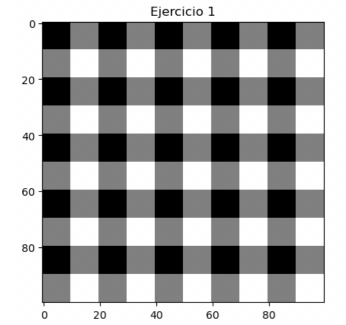

Text(0.5, 1.0, 'Ejercicio 1')

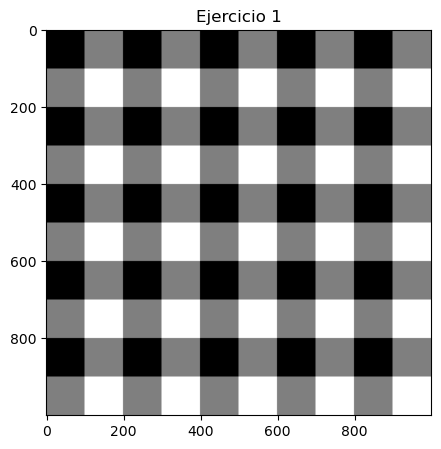

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

cell_size = 100
img_size = cell_size * 10
aux = np.zeros(shape=(img_size,img_size))

R = np.ones((img_size, img_size)) * 255
G = np.ones((img_size, img_size)) * 255
B = np.ones((img_size, img_size)) * 255

for r in range(img_size):
    for c in range(img_size):
        black = ((r//cell_size)%2 == 0) and ((c//cell_size)%2 == 0)
        gray = ((r//cell_size)%2 == 0) and ((c//cell_size)%2 == 1) or ((r//cell_size)%2 == 1) and ((c//cell_size)%2 == 0)
        if(gray):
            R[r][c] = 127 
            G[r][c] = 127 
            B[r][c] = 127 
        if(black):
            R[r][c] = 0 
            G[r][c] = 0 
            B[r][c] = 0 

aux = np.dstack((R,G,B))
aux = np.array(aux,dtype=int)


        
fig,axs = plt.subplots(1,1,figsize=(5,5))
axs.imshow(aux, "gray")
axs.set_title("Ejercicio 1")


Ejercicio 2.
Genera una imagen como la de referencia.

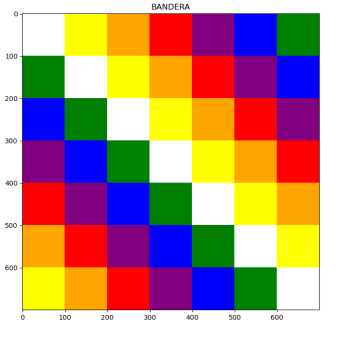

Text(0.5, 1.0, 'BANDERA')

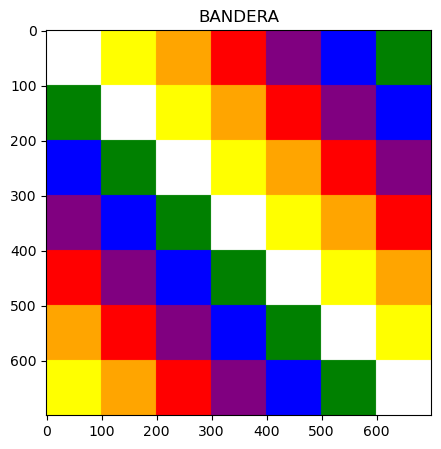

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

colors = [
    [255,255,255],
    [255,255,0],
    [255,165,0],
    [255,0,0],
    [128,0,128],
    [0,0,255],
    [0,128,0],
]
img_size = 700
aux = np.zeros(shape=(img_size,img_size))

R = np.ones((img_size, img_size))*255
G = np.ones((img_size, img_size))*255
B = np.ones((img_size, img_size))*255

for r in range(img_size):
    for c in range(img_size):
        xc = c//100
        yc = r//100
        col = colors[((xc-yc) % 7)]
        R[r][c] = col[0] 
        G[r][c] = col[1] 
        B[r][c] = col[2] 

aux = np.dstack((R,G,B))
aux = np.array(aux,dtype=int)

fig,axs = plt.subplots(1,1,figsize=(5,5))
axs.imshow(aux)
axs.set_title("BANDERA")



Ejercicio 3.
Haciendo uso de la imagen1.jpg obtiene el siguiente resultado.

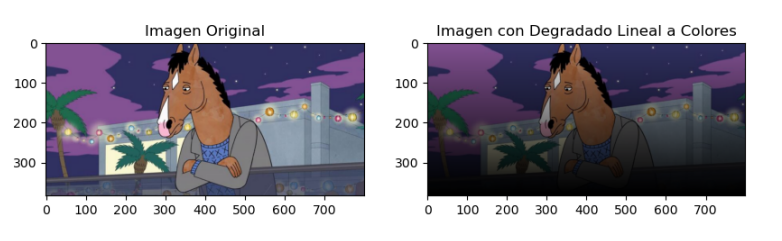

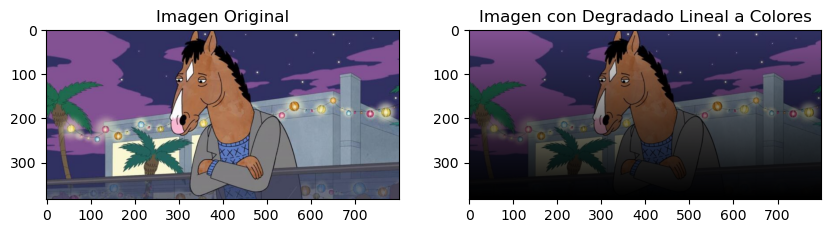

In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

rawimg = cv2.imread("imagen1.jpg")
rgbimg = cv2.cvtColor(rawimg, cv2.COLOR_BGR2RGB)

alto, ancho, ch = rgbimg.shape

degradado = np.linspace(1, 0, alto, dtype=np.float32).reshape(alto, 1, 1)
degradado = np.repeat(degradado, ancho, axis=1)
degradado = np.repeat(degradado, ch, axis=2)

result = (rgbimg * degradado).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(rgbimg)
axs[0].set_title("Imagen Original")
axs[1].imshow(result)
axs[1].set_title("Imagen con Degradado Lineal a Colores")

plt.show()


Ejercicio 4
Haciendo uso de la imagen1.jpg obtiene el siguiente resultado.

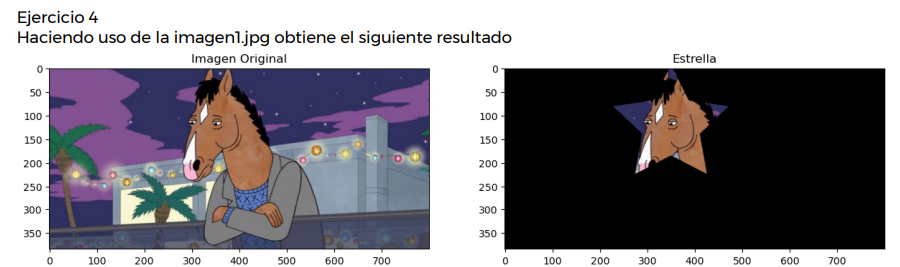

Text(0.5, 1.0, 'Triangulo')

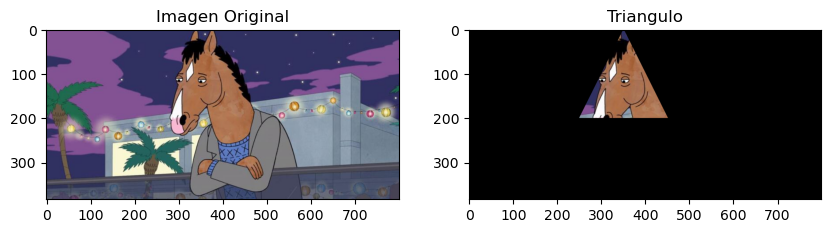

In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

rawimg = cv2.imread("imagen1.jpg")
rgbimg = cv2.cvtColor(rawimg, cv2.COLOR_BGR2RGB)
alto, ancho, ch = rgbimg.shape

mask = np.zeros((alto, ancho), dtype=np.uint8)
x0, y0 = 350, 0
puntos = np.array([
    [x0, y0], 
    [x0 - 100, y0 + 200],  
    [x0 + 100, y0 + 200]
], np.int32)
puntos = puntos.reshape((-1, 1, 2))

cv2.fillPoly(mask, [puntos], 255)

result = cv2.bitwise_and(rgbimg, rgbimg, mask=mask)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(rgbimg)
axs[0].set_title("Imagen Original")
axs[1].imshow(result)
axs[1].set_title("Triangulo")



Ejercicio 5.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), genera su
histograma por canales, solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de
preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes
titulos, guarda todas las imágenes resultantes con sus nombres.

Teoría:
1. ¿A que nos referimos si hablamos de una imagen digital?

Nos referimos a una imagen que es tratada mediante computadoras y la representacion de esta se realiza de manera logica almacenando la informacion de colores en bits.

2. ¿Qué es la profundidad del color ?

Con eso nos referimos a la cantidad de colores diferentes que puede mostrar una imagen por cada uno de sus pixeles. Por ejemplo, una imagen con una profundidad de 8 bits indica que cada pixel puede representar hasta 256 colores distintos (2^8).

3. ¿Cuál es la diferencia entre CMKY y RGB?
Las principales diferencia son: en CMYK los colores son aditivos, destinado a impresion; y en RGB los colores son sustractivos, destinado a pantallas.

CMYK es un estandard de color que se usa para impresiones, se les llama colores aditivos porque para obtener negro hay que aumentar pigmento, se compone de Cyan, Magenta, Yellow (Amarillo) y Key(Negro).

RGB en cambio un estandard color para pantallas y los colores son sustractivos, por lo cual para obtener el negro hay que usar menos pigmento o en este caso luz, se compone de Red (Rojo), Green (Verde) y Blue (Azul). 